In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

X, y = fetch_openml("adult", version=2, as_frame=True, return_X_y=True)

df = X.copy()
df['target'] = y

print(df.head())
print(df.shape)
print(df.info())
print(df.describe(include='all'))
print(df['target'].value_counts())

   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country target  
0       

In [2]:
print(df.isnull().sum())

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
target               0
dtype: int64


In [3]:
for col in ['workclass', 'occupation', 'native-country']:
    print(col)
    print(df[col].value_counts(dropna=False).head(10))
    print()

workclass
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

occupation
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
NaN                  2809
Transport-moving     2355
Handlers-cleaners    2072
Name: count, dtype: int64

native-country
native-country
United-States    43832
Mexico             951
NaN                857
Philippines        295
Germany            206
Puerto-Rico        184
Canada             182
El-Salvador        155
India              151
Cuba               138
Name: count, dtype: int64



In [4]:
for col in ['workclass', 'occupation', 'native-country']:
    print(col)
    print(df[col].value_counts(dropna=False).head(10))
    print()

workclass
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

occupation
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
NaN                  2809
Transport-moving     2355
Handlers-cleaners    2072
Name: count, dtype: int64

native-country
native-country
United-States    43832
Mexico             951
NaN                857
Philippines        295
Germany            206
Puerto-Rico        184
Canada             182
El-Salvador        155
India              151
Cuba               138
Name: count, dtype: int64



In [5]:
X = df.drop(columns=['target'])
y = df['target']

In [6]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numeric_features)

['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [9]:
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_features)

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


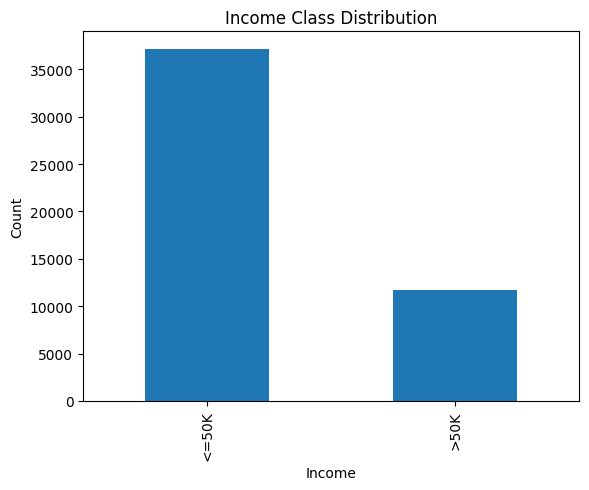

In [8]:
df['target'].value_counts().plot(kind='bar')
plt.title('Income Class Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

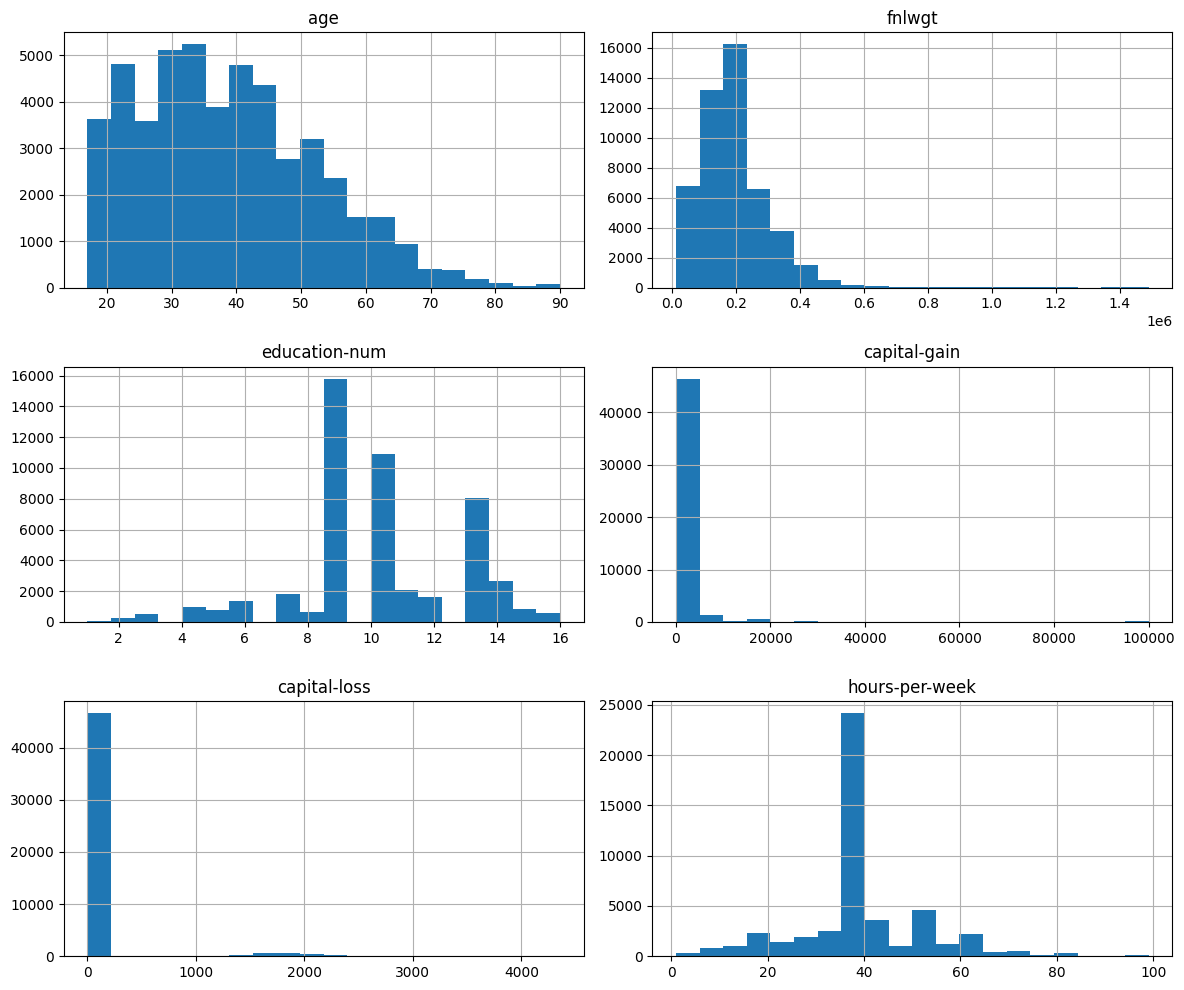

In [10]:
num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

df[num_cols].hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

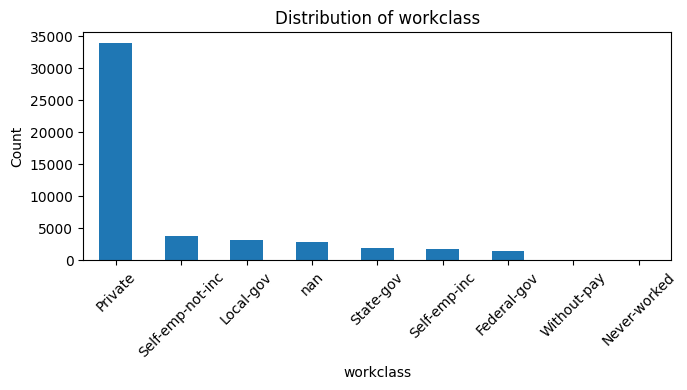

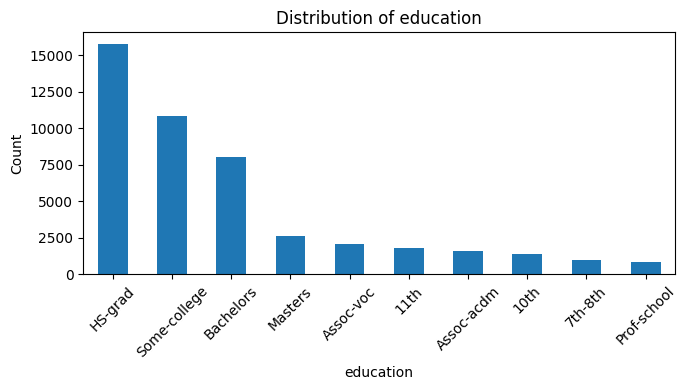

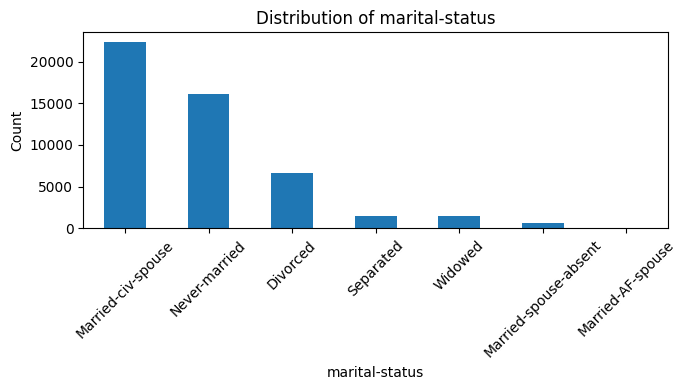

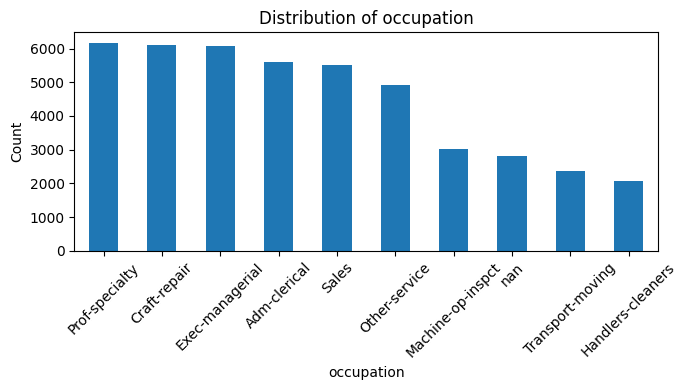

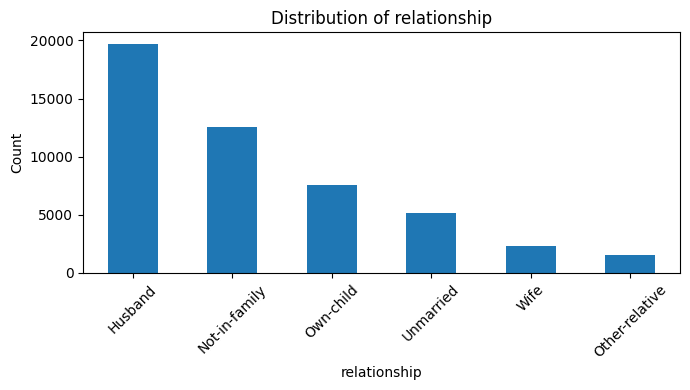

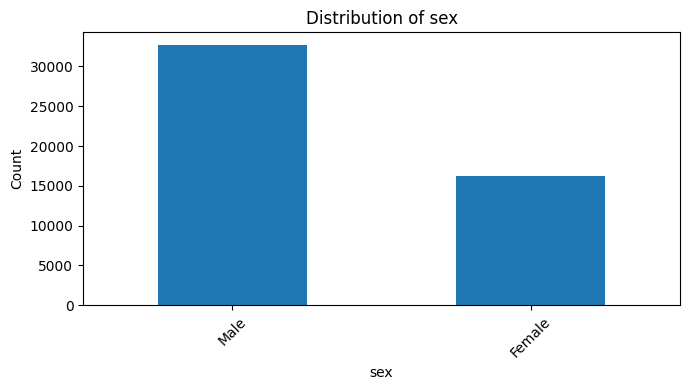

In [11]:
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'sex']

for col in cat_cols:
    plt.figure(figsize=(7, 4))
    df[col].value_counts(dropna=False).head(10).plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

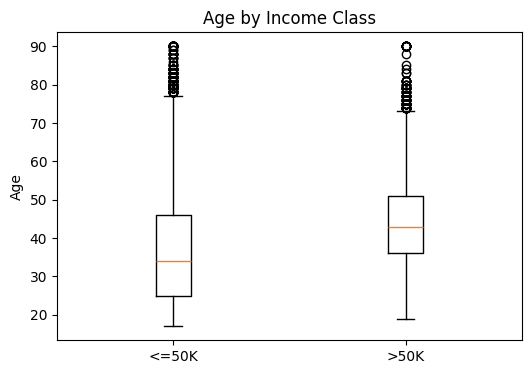

In [12]:
plt.figure(figsize=(6, 4))
data_to_plot = [
    df[df['target'] == '<=50K']['age'].dropna(),
    df[df['target'] == '>50K']['age'].dropna()
]
plt.boxplot(data_to_plot, tick_labels=['<=50K', '>50K'])
plt.title('Age by Income Class')
plt.ylabel('Age')
plt.show()

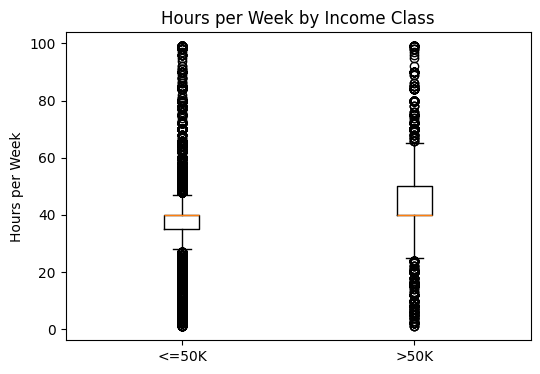

In [13]:
plt.figure(figsize=(6, 4))
data_to_plot = [
    df[df['target'] == '<=50K']['hours-per-week'].dropna(),
    df[df['target'] == '>50K']['hours-per-week'].dropna()
]
plt.boxplot(data_to_plot, tick_labels=['<=50K', '>50K'])
plt.title('Hours per Week by Income Class')
plt.ylabel('Hours per Week')
plt.show()

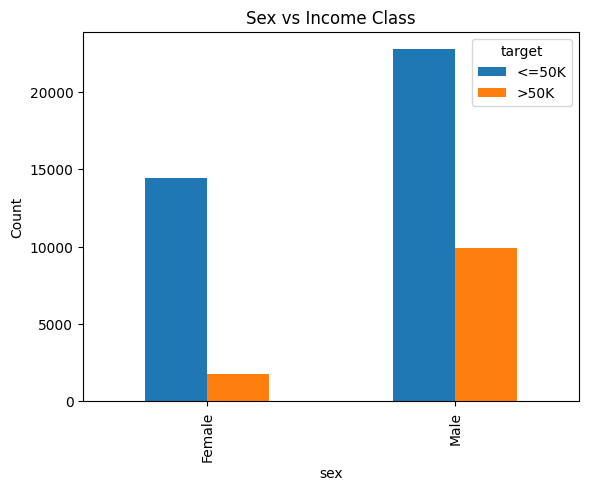

In [14]:
pd.crosstab(df['sex'], df['target']).plot(kind='bar')
plt.title('Sex vs Income Class')
plt.ylabel('Count')
plt.show()

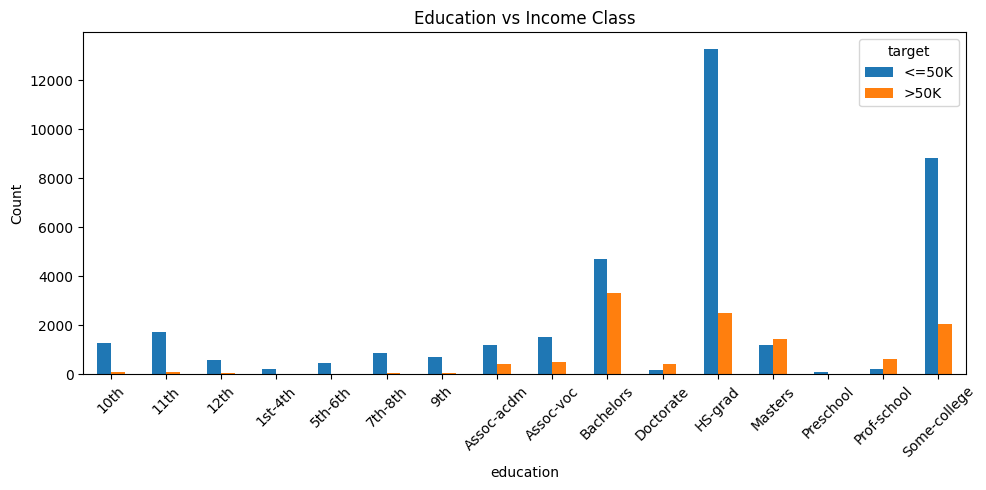

In [15]:
pd.crosstab(df['education'], df['target']).plot(kind='bar', figsize=(10, 5))
plt.title('Education vs Income Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = df.drop(columns=['target'])
y = df['target']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Accuracy: 0.8523902139420616
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      7431
        >50K       0.74      0.59      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.85      0.85      0.85      9769



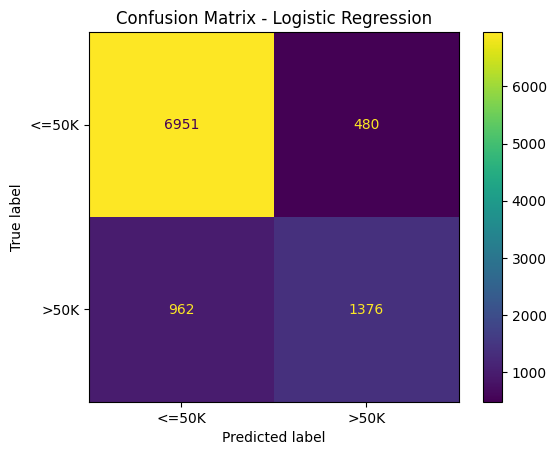

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=2000))
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Accuracy: 0.8583273620636708
              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      7431
        >50K       0.79      0.55      0.65      2338

    accuracy                           0.86      9769
   macro avg       0.83      0.75      0.78      9769
weighted avg       0.85      0.86      0.85      9769



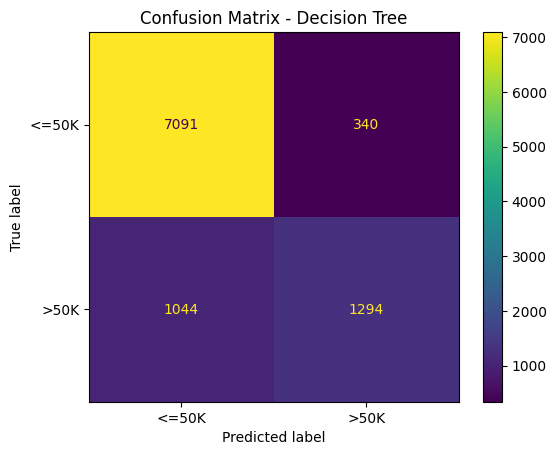

In [18]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Accuracy: 0.8594533729143208
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.74      0.64      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.85      0.86      0.86      9769



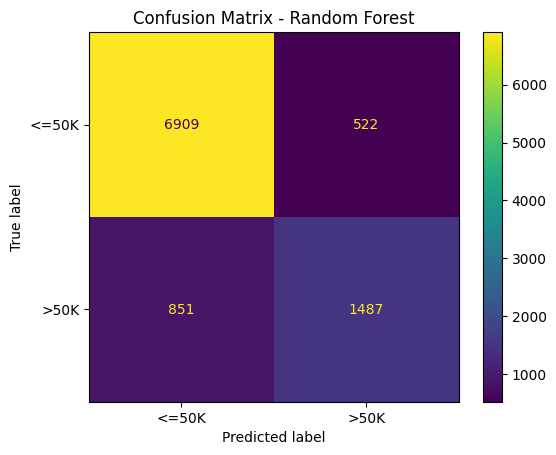

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest")
plt.show()

Accuracy: 0.8594533729143208
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.74      0.64      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.85      0.86      0.86      9769



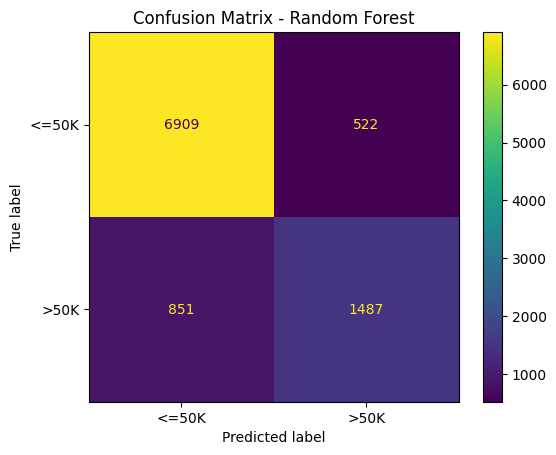

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [21]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.852390
1        Decision Tree  0.858327
2        Random Forest  0.859453


Adult Income dataset is a binary classification problem with both numeric and categorical features. The target variable is imbalanced, with more individuals in the <=50K class than in the >50K class. Numeric features such as age, education-num, and hours-per-week, along with categorical features such as education, occupation, and marital-status, appeared informative during EDA. Missing values in categorical fields were handled using imputation, and categorical features were one-hot encoded. Logistic Regression, Decision Tree, and Random Forest were trained and compared using accuracy, precision, recall, F1-score, and confusion matrix.